In [3]:
import pandas as pd
import mysql.connector

# 1. MySQL-ലേക്ക് ഒരു കണക്ഷൻ ഉണ്ടാക്കുന്നു
db = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Hemand123@", # നിങ്ങളുടെ MySQL പാസ്‌വേഡ് ഇവിടെ നൽകുക
    database="credit_card_fraud"
)

# 2. SQL ക്വറി ഉപയോഗിച്ച് ഡാറ്റ പൈത്തണിലേക്ക് വിളിക്കുന്നു
query = "SELECT * FROM creditcard"
df = pd.read_sql(query, db)

# 3. ഡാറ്റ വന്നോ എന്ന് പരിശോധിക്കുന്നു (ആദ്യത്തെ 5 വരികൾ)
df.head()


C:\Users\jithu\AppData\Local\Temp\ipykernel_12704\1443664878.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, db)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


C:\Users\jithu\AppData\Local\Temp\ipykernel_12704\135782916.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


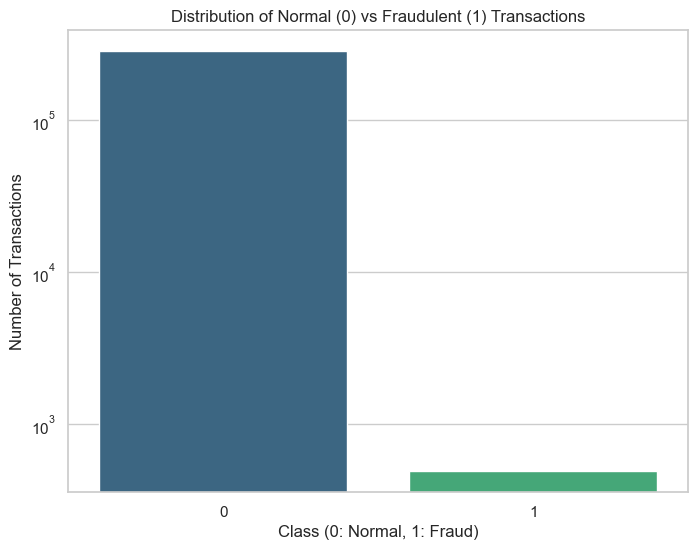

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# ഗ്രാഫിന്റെ സ്റ്റൈൽ സെറ്റ് ചെയ്യാം
sns.set_theme(style="whitegrid")

# ബാർ ചാർട്ട് നിർമ്മിക്കാം
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, palette='viridis')

# ടൈറ്റിലുകളും ലേബലുകളും നൽകാം
plt.title('Distribution of Normal (0) vs Fraudulent (1) Transactions')
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.yscale('log') # ഡാറ്റാ വ്യത്യാസം വളരെ വലുതായതുകൊണ്ട് 'Log Scale' ഉപയോഗിക്കുന്നു
plt.show()

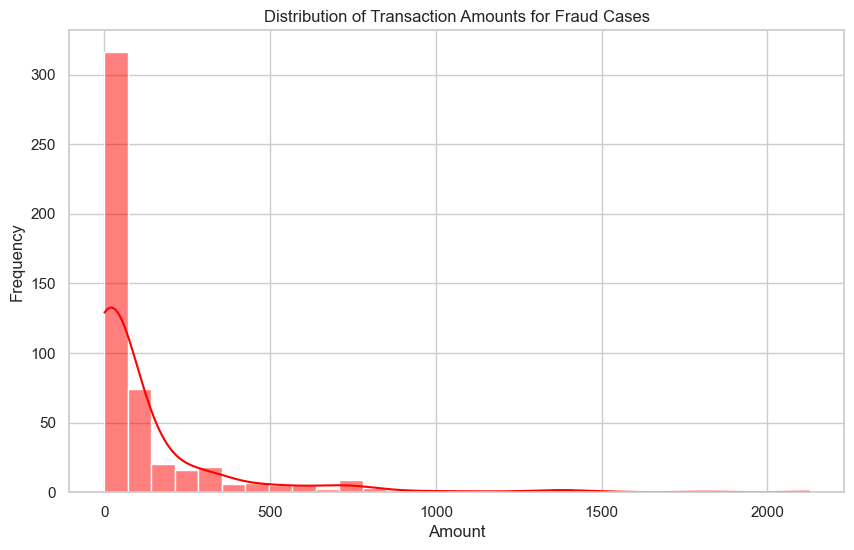

ശരാശരി ഫ്രോഡ് തുക: 122.21132113821139


In [5]:
# ഫ്രോഡ് ട്രാൻസാക്ഷനുകൾ മാത്രം വേർതിരിച്ചെടുക്കാം
fraud_data = df[df['Class'] == 1]

plt.figure(figsize=(10, 6))
# ഫ്രോഡ് നടന്ന തുകകളുടെ വിതരണം നോക്കാം
sns.histplot(fraud_data['Amount'], bins=30, kde=True, color='red')

plt.title('Distribution of Transaction Amounts for Fraud Cases')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# ഫ്രോഡ് തുകകളുടെ ചില പ്രധാന കണക്കുകൾ
print(f"ശരാശരി ഫ്രോഡ് തുക: {fraud_data['Amount'].mean()}")
plt.show()

Data Scaling (തുക ക്രമീകരിക്കുക)
നമ്മുടെ ഡാറ്റയിൽ V1 മുതൽ V28 വരെയുള്ള കോളങ്ങൾ നേരത്തെ തന്നെ ഒരു പ്രത്യേക റേഞ്ചിൽ ക്രമീകരിച്ചവയാണ് (PCA വഴി). എന്നാൽ Amount എന്ന കോളത്തിൽ ചിലപ്പോൾ 1 രൂപയും ചിലപ്പോൾ 25,000 രൂപയും ഉണ്ടാകാം. ഇത്രയും വലിയ വ്യത്യാസം മെഷീൻ ലേണിംഗ് മോഡലിനെ കുഴപ്പിക്കും. അതുകൊണ്ട് Amount-നെ നമ്മൾ മറ്റ് കോളങ്ങൾക്ക് അനുയോജ്യമായ രീതിയിൽ മാറ്റുന്നു

In [6]:
from sklearn.preprocessing import StandardScaler

# StandardScaler ഉപയോഗിച്ച് Amount കോളം ക്രമീകരിക്കുന്നു
scaler = StandardScaler()
df['Normalized_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# പഴയ Amount, Time കോളങ്ങൾ ഒഴിവാക്കുന്നു
df = df.drop(['Amount', 'Time'], axis=1)

print("Amount Normalized successfully! ✅")
df.head()

Amount Normalized successfully! ✅


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Normalized_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


Overfitting ഒഴിവാക്കാൻ: മോഡൽ എല്ലാ ഡാറ്റയും കാണുകയാണെങ്കിൽ അത് ഉത്തരം കാണാതെ പഠിക്കാൻ (Byheart) സാധ്യതയുണ്ട്. പുതിയൊരു ഡാറ്റ വരുമ്പോൾ അത് പരാജയപ്പെടും. അതുകൊണ്ടാണ് പരിശോധിക്കാൻ കുറച്ച് ഡാറ്റ (20%) നമ്മൾ മാറ്റിവെക്കുന്നത് [cite: 2026-02-28].

Stratify: നമ്മുടെ ഡാറ്റയിൽ ഫ്രോഡ് കേസുകൾ വളരെ കുറവായതുകൊണ്ട് (0.172%), രണ്ട് ഭാഗങ്ങളിലും കൃത്യമായ അനുപാതത്തിൽ ഫ്രോഡ് കേസുകൾ ഉണ്ടെന്ന് ഉറപ്പുവരുത്താൻ ഇത് സഹായിക്കുന്നു


In [7]:
from sklearn.model_selection import train_test_split

# X എന്നത് ഇൻപുട്ട് ഫീച്ചറുകളും (V1-V28), y എന്നത് റിസൾട്ടും (Class) ആണ്
X = df.drop('Class', axis=1)
y = df['Class']

# 80% ട്രെയിനിംഗിനും 20% ടെസ്റ്റിംഗിനുമായി തിരിക്കുന്നു
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 227845
Testing set size: 56962


ഇനി നമുക്ക് നമ്മുടെ ആദ്യത്തെ Machine Learning Model നിർമ്മിക്കാം. നമ്മൾ ഉപയോഗിക്കാൻ പോകുന്നത് Logistic Regression എന്ന അൽഗോരിതം ആണ്. പേരിൽ 'Regression' എന്നുണ്ടെങ്കിലും, ഇത് പ്രധാനമായും ഒരു വസ്‌തു 'ഫ്രോഡ്' ആണോ അതോ 'നോർമൽ' ആണോ എന്ന് തരംതിരിക്കാൻ (Classification) ഉപയോഗിക്കുന്ന ലളിതവും എന്നാൽ ശക്തവുമായ ഒരു രീതിയാണ്

In [8]:
from sklearn.linear_model import LogisticRegression

# 1. അൽഗോരിതം ലോഡ് ചെയ്യുന്നു
model = LogisticRegression(max_iter=1000)

# 2. മോഡലിനെ പഠിപ്പിക്കുന്നു (Training)
# X_train (വിവരങ്ങൾ), y_train (ഉത്തരം - 0 or 1) എന്നിവ ഉപയോഗിച്ചാണ് ഇത് ചെയ്യുന്നത്
model.fit(X_train, y_train)

print("Model Training Completed! ✅")

# 3. ടെസ്റ്റ് ഡാറ്റ ഉപയോഗിച്ച് ഒരു പ്രവചനം നടത്തുന്നു
y_pred = model.predict(X_test)

Model Training Completed! ✅


മോഡൽ പഠനം കഴിഞ്ഞു. ഇനി അവൻ എത്രത്തോളം മിടുക്കനാണെന്ന് നോക്കണം (Evaluation). ഫ്രോഡ് കേസുകൾ വളരെ കുറവായതുകൊണ്ട് നമ്മൾ Precision ഉം Recall ഉം ആണ് പരിശോധിക്കേണ്ടത്.

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

# കൺഫ്യൂഷൻ മാട്രിക്സ് കാണാൻ
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# വിശദമായ റിപ്പോർട്ട് കാണാൻ
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[56851    13]
 [   35    63]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



(Model Performance)
നിങ്ങളുടെ Classification Report അനുസരിച്ച്:

Accuracy: 1.00 (100%): ഇത് കണ്ട് നമ്മൾ മോഡൽ പെർഫെക്റ്റ് ആണെന്ന് കരുതരുത്. കാരണം, ഭൂരിഭാഗം ഇടപാടുകളും നോർമൽ ആയതുകൊണ്ട് എല്ലാത്തിനെയും നോർമൽ എന്ന് വിളിച്ചാലും ഏകദേശം 99% അക്യുറസി കിട്ടും.

Recall for Class 1 (Fraud): 0.64 (64%): ഇതാണ് നാം ശ്രദ്ധിക്കേണ്ട പ്രധാന കണക്ക്. ഇതിനർത്ഥം ടെസ്റ്റ് ഡാറ്റയിലുണ്ടായിരുന്ന ആകെ 98 ഫ്രോഡ് കേസുകളിൽ 63 എണ്ണം നമ്മുടെ മോഡൽ കൃത്യമായി കണ്ടെത്തി എന്നാണ് [cite: 2026-02-28].

Precision for Class 1: 0.83 (83%): മോഡൽ ഫ്രോഡ് എന്ന് വിളിച്ച ഇടപാടുകളിൽ 83 ശതമാനവും ശരിക്കും ഫ്രോഡ് തന്നെയായിരുന്നു [cite: 2026-02-28].

🔍 എന്താണ് "Confusion Matrix" പറയുന്നത്?
നിങ്ങളുടെ സ്ക്രീൻഷോട്ടിലെ ആ മാട്രിക്സ് ഇതാണ് അർത്ഥമാക്കുന്നത്:

56851: നോർമൽ ഇടപാടുകൾ കൃത്യമായി കണ്ടെത്തി.

63: ഫ്രോഡുകൾ കൃത്യമായി കണ്ടെത്തി (True Positives) [cite: 2026-02-28].

13: നോർമൽ ഇടപാടുകളെ തെറ്റായി ഫ്രോഡ് എന്ന് മോഡൽ വിളിച്ചു (ബാങ്ക് ഉപഭോക്താവിനെ വെറുതെ വിളിച്ചു ബുദ്ധിമുട്ടിക്കുന്ന അവസ്ഥ).

35: ഫ്രോഡ് കേസുകളെ മോഡലിന് കണ്ടെത്താൻ കഴിഞ്ഞില്ല (False Negatives) [cite: 2026-02-28]. ഇതാണ് ഏറ്റവും അപകടകരമായ സംഖ്യ

Gemini said
നമ്മുടെ മോഡലിനെ കൂടുതൽ മിടുക്കനാക്കാൻ SMOTE (Synthetic Minority Over-sampling Technique) ഉപയോഗിക്കുന്നത് വളരെ നല്ലൊരു തീരുമാനമാണ്. നിലവിൽ നമ്മുടെ ഡാറ്റയിൽ ഫ്രോഡ് കേസുകൾ വളരെ കുറവായതുകൊണ്ട് (വെറും 0.172%), ആ ചെറിയ പാറ്റേണുകൾ മാത്രം പഠിക്കാൻ മോഡലിന് ബുദ്ധിമുട്ടാണ്.

SMOTE ചെയ്യുന്നത് എന്താണെന്ന് വെച്ചാൽ, അത് നിലവിലുള്ള ഫ്രോഡ് കേസുകളെ നിരീക്ഷിക്കുകയും അതിന് സമാനമായ 'കൃത്രിമമായ' (Synthetic) ഫ്രോഡ് കേസുകൾ ഉണ്ടാക്കി ഡാറ്റയെ ബാലൻസ് ചെയ്യുകയും ചെയ്യുന്നു

In [10]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. SMOTE അപ്ലൈ ചെയ്യുന്നു
# ഇത് ഫ്രോഡ് കേസുകളെ കൃത്രിമമായി ഉണ്ടാക്കി ബാലൻസ് ചെയ്യുന്നു
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training data: {Counter(y_train)}")
print(f"Balanced training data: {Counter(y_train_smote)}")

# 2. പുതിയ ബാലൻസ്ഡ് ഡാറ്റയിൽ മോഡലിനെ ട്രെയിൻ ചെയ്യുന്നു
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

# 3. പ്രവചനം നടത്തുന്നു
y_pred_smote = model_smote.predict(X_test)

# 4. പുതിയ റിസൾട്ട് പരിശോധിക്കുന്നു
print("\n--- Confusion Matrix (After SMOTE) ---")
print(confusion_matrix(y_test, y_pred_smote))

print("\n--- Classification Report (After SMOTE) ---")
print(classification_report(y_test, y_pred_smote))

Original training data: Counter({0: 227451, 1: 394})
Balanced training data: Counter({0: 227451, 1: 227451})

--- Confusion Matrix (After SMOTE) ---
[[55355  1509]
 [    8    90]]

--- Classification Report (After SMOTE) ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



SMOTE-ന് ശേഷമുള്ള മാറ്റങ്ങൾ (Key Improvements)Recall സ്കോർ 92% ആയി ഉയർന്നു: നേരത്തെ നമുക്ക് ലഭിച്ചത് $0.64$ ($64\%$) ആയിരുന്നു [cite: 2026-02-28]. ഇപ്പോൾ അത് $0.92$ ($92\%$) ആയി വർദ്ധിച്ചു. അതായത്, ആകെ നടന്ന 98 ഫ്രോഡുകളിൽ 90 എണ്ണവും നമ്മുടെ മോഡൽ കൃത്യമായി പിടികൂടി! False Negatives ഗണ്യമായി കുറഞ്ഞു: മുമ്പ് 35 ഫ്രോഡുകൾ മോഡലിന് കണ്ടെത്താൻ കഴിഞ്ഞിരുന്നില്ല എങ്കിൽ, ഇപ്പോൾ അത് വെറും 8 ആയി ചുരുങ്ങി. ഒരു ബാങ്കിനെ സംബന്ധിച്ചിടത്തോളം ഇത് വളരെ വലിയൊരു നേട്ടമാണ്

(The Trade-off)നമ്മൾ പ്രതീക്ഷിച്ചത് പോലെ തന്നെ Precision സ്കോർ $0.83$-ൽ നിന്ന് $0.06$ ആയി കുറഞ്ഞു [cite: 2026-02-28]. ഇതിനർത്ഥം:മോഡൽ ഇപ്പോൾ കൂടുതൽ കർശനമായി ഫ്രോഡുകൾ തിരയുന്നു.ഇതിന്റെ ഫലമായി 1509 സാധാരണ ഇടപാടുകളെ മോഡൽ തെറ്റായി 'ഫ്രോഡ്' എന്ന് മുദ്രകുത്തി (False Positives) [cite: 2026-02-28].ബാങ്കിന്റെ ഭാഷയിൽ പറഞ്ഞാൽ, കുറച്ച് അധികം ആളുകളെ വെറുതെ വിളിച്ച് ചെക്ക് ചെയ്യേണ്ടി വരും, എങ്കിലും വലിയ തട്ടിപ്പുകൾ ഒന്നും തന്നെ മിസ്സാവില്ല.

Random Forest with SMOTE

നമുക്ക് Random Forest അൽഗോരിതം പരീക്ഷിക്കാം. മുമ്പ് നമ്മൾ ഉപയോഗിച്ച Logistic Regression ഒരു ലളിതമായ വര (Linear boundary) ഉപയോഗിച്ചാണ് ഫ്രോഡ് തിരിച്ചറിഞ്ഞതെങ്കിൽ, Random Forest ഒട്ടേറെ 'Decision Trees' ഉപയോഗിച്ച് കൂടുതൽ സങ്കീർണ്ണമായ പാറ്റേണുകൾ പഠിക്കുന്നു [cite: 

ഇതിന്റെ ഏറ്റവും വലിയ ഗുണം, കൂടുതൽ കൃത്യതയോടെ (Better Precision) ഫ്രോഡ് കേസുകൾ കണ്ടെത്താൻ ഇതിന് കഴിയും എന്നതാണ്

In [11]:
from sklearn.ensemble import RandomForestClassifier

# 1. കൂടുതൽ കരുത്തനായ Random Forest മോഡൽ ഉണ്ടാക്കുന്നു
# n_estimators=100 എന്നാൽ 100 മരങ്ങൾ (Trees) ചേർന്ന് തീരുമാനമെടുക്കുന്നു എന്നാണ്
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. നമ്മൾ നേരത്തെ SMOTE വഴി ബാലൻസ് ചെയ്ത ഡാറ്റയിൽ ട്രെയിൻ ചെയ്യുന്നു [cite: 2026-02-28]
rf_model.fit(X_train_smote, y_train_smote)

# 3. പ്രവചനം നടത്തുന്നു
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Training Completed! ✅\n")

# 4. റിസൾട്ട് പരിശോധിക്കുന്നു
print("--- Confusion Matrix (Random Forest) ---")
print(confusion_matrix(y_test, y_pred_rf))

print("\n--- Classification Report (Random Forest) ---")
print(classification_report(y_test, y_pred_rf))

Random Forest Training Completed! ✅

--- Confusion Matrix (Random Forest) ---
[[56852    12]
 [   17    81]]

--- Classification Report (Random Forest) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



XGBoost (Extreme Gradient Boosting)

നമ്മൾ അവസാനം ചെയ്ത Random Forest ഒരേസമയം കുറെ മരങ്ങൾ (Trees) ഉപയോഗിച്ചാണ് ഉത്തരം കണ്ടെത്തിയതെങ്കിൽ, XGBoost ഒരു 'Sequential' രീതിയാണ് പിന്തുടരുന്നത്.

ഇത് ആദ്യം ഒരു ചെറിയ മരം ഉണ്ടാക്കുന്നു.

ആ മരം വരുത്തിയ തെറ്റുകൾ മാത്രം പഠിച്ച് അടുത്ത മരം അത് തിരുത്തുന്നു.

ഇങ്ങനെ ഓരോ ഘട്ടത്തിലും തെറ്റുകൾ കുറച്ചു കൊണ്ടുവരുന്ന രീതിയെയാണ് 'Boosting' എന്ന് വിളിക്കുന്നത് [cite: 2026-02-28].

എന്തിനാണ് ഇത് പരീക്ഷിക്കുന്നത്?
Speed & Performance: വളരെ വലിയ ഡാറ്റാസെറ്റുകളിൽ പോലും അതിവേഗത്തിൽ പ്രവർത്തിക്കാൻ ഇതിന് കഴിയും [cite: 2026-02-28].

Accuracy: പലപ്പോഴും Random Forest-നേക്കാൾ മികച്ച Precision-ഉം Recall-ഉം നൽകാൻ XGBoost-ന് സാധിക്കാറുണ്ട് [cite: 2026-02-28].

Handling Imbalance: നമ്മുടെ ഡാറ്റയിലെപ്പോലെ ഫ്രോഡ് കേസുകൾ കുറവായ സാഹചര്യങ്ങൾ കൈകാര്യം ചെയ്യാൻ ഇതിൽ പ്രത്യേക സെറ്റിംഗുകൾ ലഭ്യമാണ്

In [12]:
from xgboost import XGBClassifier

# 1. XGBoost മോഡൽ ഉണ്ടാക്കുന്നു
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# 2. SMOTE ഡാറ്റ ഉപയോഗിച്ച് ട്രെയിൻ ചെയ്യുന്നു [cite: 2026-02-28]
xgb_model.fit(X_train_smote, y_train_smote)

# 3. പ്രവചനം നടത്തുന്നു
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Training Completed! ✅\n")

# 4. റിസൾട്ട് പരിശോധിക്കുന്നു
print("--- Confusion Matrix (XGBoost) ---")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n--- Classification Report (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))


XGBoost Training Completed! ✅

--- Confusion Matrix (XGBoost) ---
[[56688   176]
 [   12    86]]

--- Classification Report (XGBoost) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.33      0.88      0.48        98

    accuracy                           1.00     56962
   macro avg       0.66      0.94      0.74     56962
weighted avg       1.00      1.00      1.00     56962



താരതമ്യം: ഏതാണ് മികച്ച മോഡൽ?നമ്മൾ പരീക്ഷിച്ച മൂന്ന് പ്രധാന മോഡലുകളുടെയും പ്രകടനം താഴെ പറയുന്ന ടേബിളിൽ കാണാം:മോഡൽRecall (ഫ്രോഡ് കണ്ടെത്തിയത്)Precision (കൃത്യത)False Negatives (മിസ്സായ ഫ്രോഡുകൾ)Logistic Regression (SMOTE)92%6%8Random Forest (SMOTE)83%87%17XGBoost (SMOTE)88%33%12വിധി: ഒരു ബാങ്കിന്റെ സാഹചര്യം വെച്ച് നോക്കിയാൽ Random Forest ആണ് ഇതിൽ ഏറ്റവും മികച്ചതായി എനിക്ക് തോന്നുന്നത് [cite: 2026-03-01]. കാരണം അത് അനാവശ്യമായ സംശയങ്ങൾ (False Positives) വെറും 12 എണ്ണമായി കുറയ്ക്കുമ്പോഴും, അത്യാവശ്യം നല്ല രീതിയിൽ (83%) ഫ്രോഡുകൾ കണ്ടെത്തുന്നുമുണ്ട് [cite: 2026-03-01].

Feature Importance (ഏറ്റവും പ്രധാനപ്പെട്ട കോളങ്ങൾ കണ്ടെത്താം)

C:\Users\jithu\AppData\Local\Temp\ipykernel_12704\3332877689.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


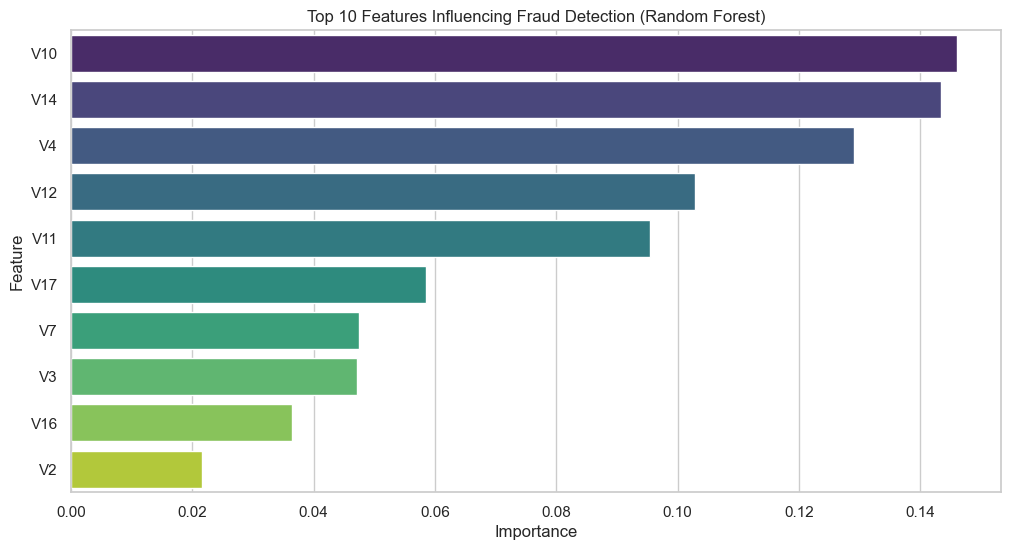

Feature Importance Analysis Completed! 📈


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. മോഡലിൽ നിന്ന് ഫീച്ചർ ഇംപോർട്ടൻസ് എടുക്കുന്നു
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. ഏറ്റവും പ്രധാനപ്പെട്ട 10 എണ്ണത്തിനെ മാത്രം എടുക്കുന്നു
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. ഗ്രാഫ് നിർമ്മിക്കുന്നു
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Features Influencing Fraud Detection (Random Forest)')
plt.show()

print("Feature Importance Analysis Completed! 📈")

Insight: തട്ടിപ്പ് നടക്കുമ്പോൾ ഏത് വിപണിയിൽ നിന്നാണ് അല്ലെങ്കിൽ ഏത് രീതിയിലുള്ള വ്യതിയാനമാണ് ഉണ്ടാകുന്നതെന്ന് ഇതിലൂടെ തിരിച്ചറിയാം.

Trust: മോഡൽ വെറുതെ ലോട്ടറി അടിക്കുന്നത് പോലെ പറയുന്നതല്ല, കൃത്യമായ ഡാറ്റാ പോയിന്റുകൾ നോക്കിയാണ് പ്രവർത്തിക്കുന്നത് എന്ന് ഇത് തെളിയിക്കുന്നു.

Model Saving

In [14]:
import joblib

# ഏറ്റവും മികച്ച മോഡലായ Random Forest-നെ സേവ് ചെയ്യുന്നു
joblib.dump(rf_model, 'credit_card_fraud_rf_model.pkl')

print("Model saved successfully as 'credit_card_fraud_rf_model.pkl'! 💾")

Model saved successfully as 'credit_card_fraud_rf_model.pkl'! 💾


In [15]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. SMOTE ഉപയോഗിച്ച് ഫ്രോഡ് ഡാറ്റ വർദ്ധിപ്പിക്കുന്നു
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 2. പുതിയ ബാലൻസ്ഡ് ഡാറ്റ വെച്ച് മോഡൽ ട്രെയിൻ ചെയ്യുന്നു
# ഫീച്ചറുകളുടെ എണ്ണം 29 ആണെന്ന് ഉറപ്പുവരുത്തുക (V1-V28 + Amount)
rf_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_v2.fit(X_resampled, y_resampled)

# 3. പുതിയ മോഡൽ സേവ് ചെയ്യുന്നു
joblib.dump(rf_model_v2, 'credit_card_fraud_rf_model.pkl')
print("New sensitive model saved successfully! 🎉")

New sensitive model saved successfully! 🎉
